In [1]:
%run geminiGeneratedHelper.ipynb 
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 10, 'axes.titlesize': 12,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 12,
    'figure.dpi': 300, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
})

In [4]:
SAMPLING_RATE = 5e6    # 5 MHz
CHIRP_BANDWIDTH = 2e6  # 1 MHz
burst_len = 1024
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/data/'
prefix = 'freeSpace_0'
i=0
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile_range_0, calibrated_channel_response_0, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

dir = '/home/hui/bladerf_sfcw_radar/data/'
prefix = 'res_0'
i=30
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile_range_res, calibrated_channel_response_res, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

#plotResults(ascan_profile_range_res, calibrated_channel_response_res, echo_response)

/tmp/ipykernel_1600215/108529707.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved as 'resEx1.eps'


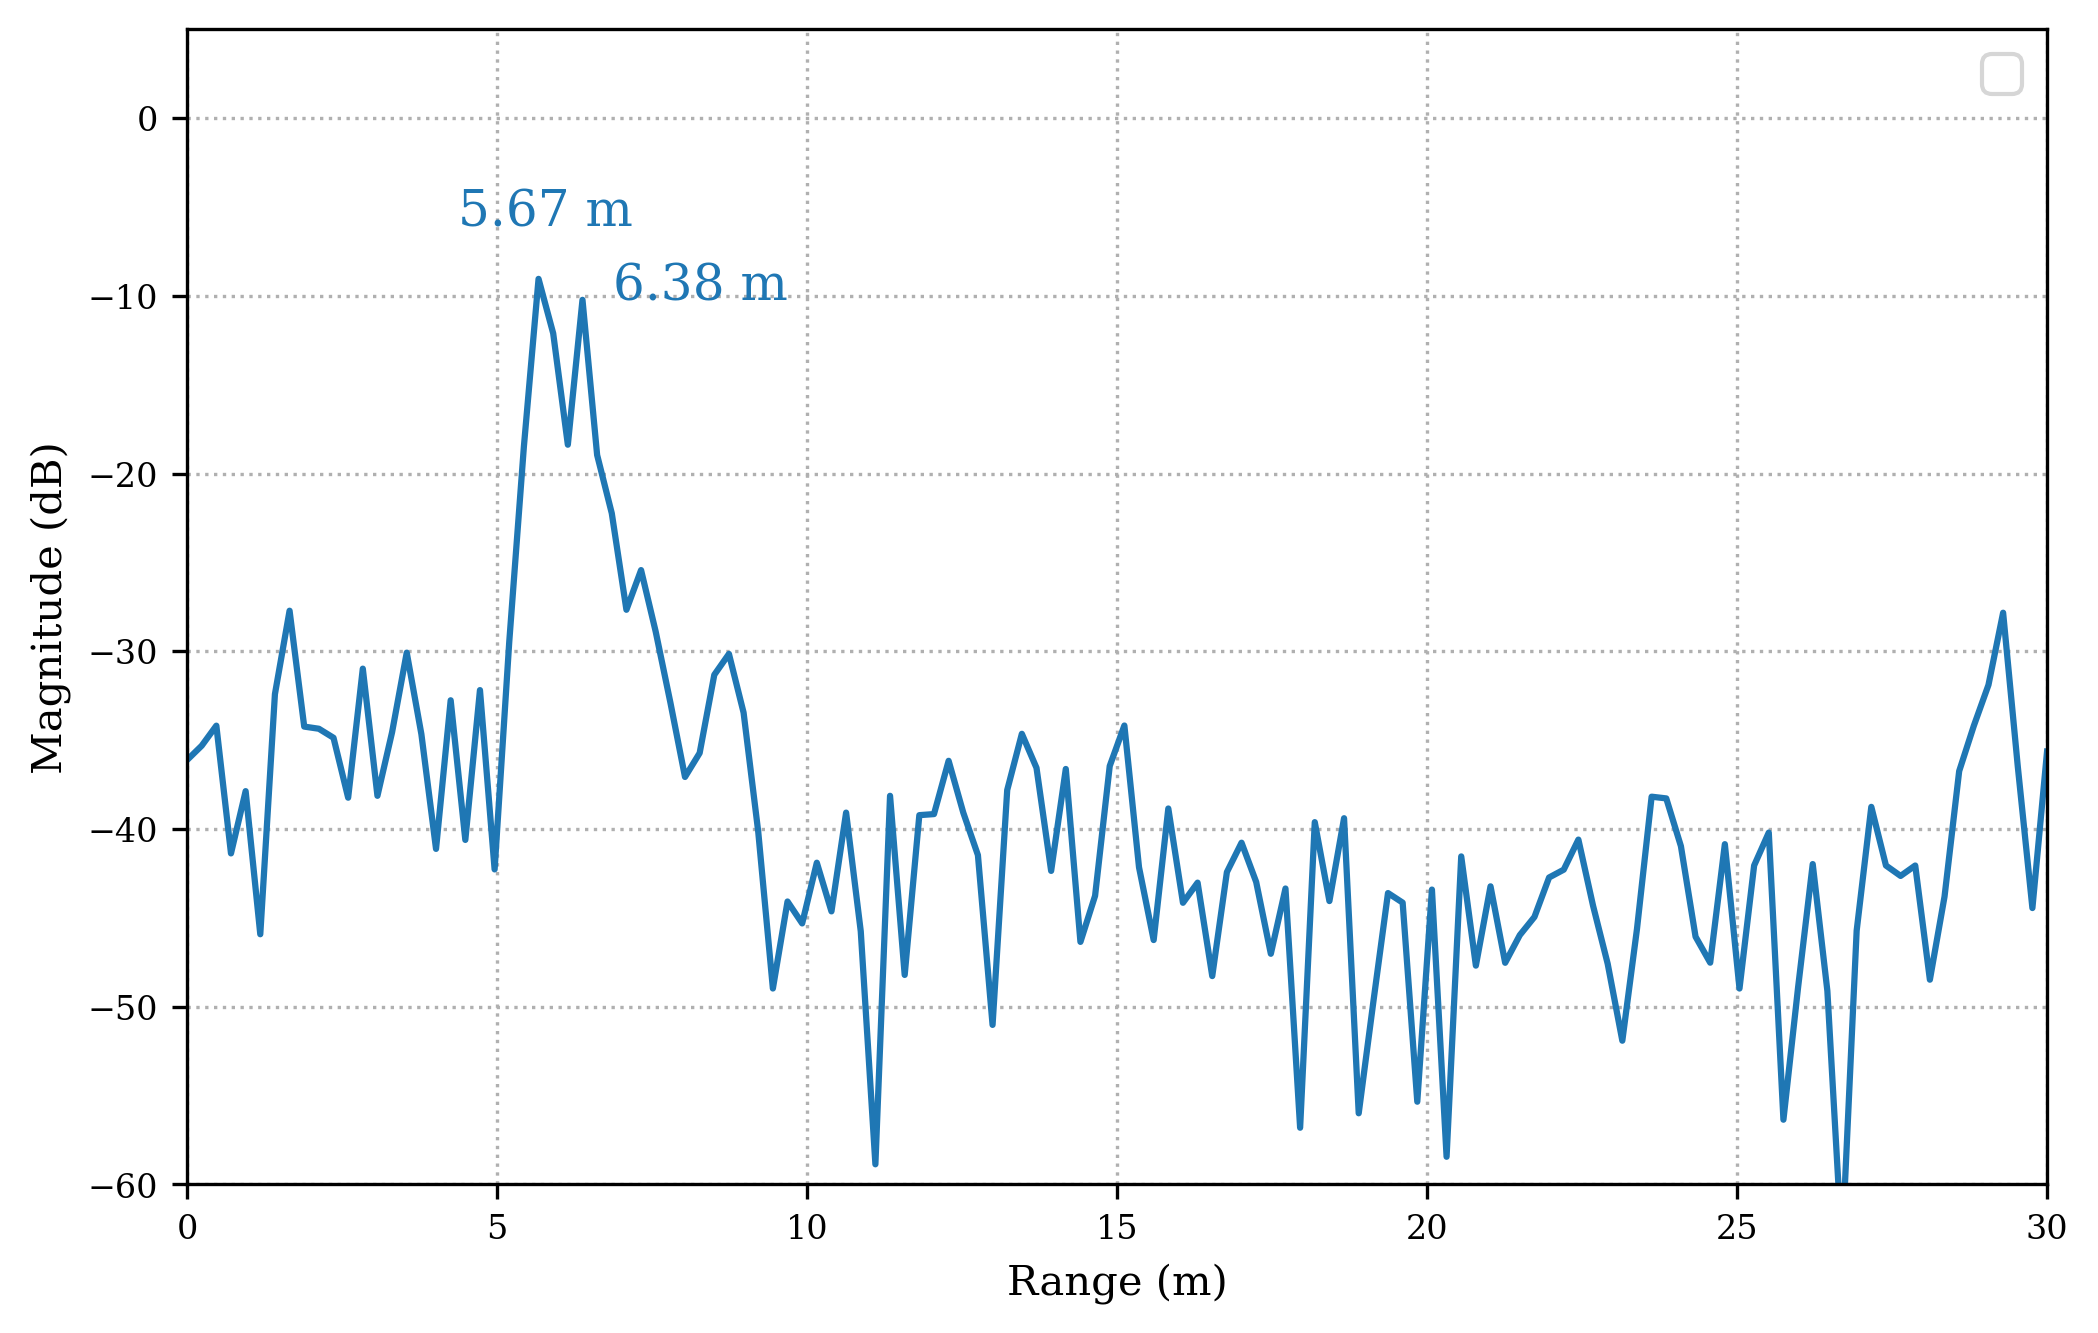

In [5]:
c = 3e8  # Speed of light
max_range = c / (2 * SAMPLING_RATE)
range_axis = np.linspace(0, max_range, num_steps)
target_positions_m = [1.8, 1.8, 3.5, 5.3]
output_filename = "resEx1.eps"

plt.figure(figsize=[8,5])

channel_response_sky_cal = calibrated_channel_response_res - calibrated_channel_response_0
a_scan_sky_cal = np.fft.ifft(channel_response_sky_cal)
ascan_db = 20 * np.log10(np.abs(a_scan_sky_cal) + 1e-12) - 5
plt.plot(range_axis,ascan_db)
peak_index = np.argmax(ascan_db)
peak_range = range_axis[peak_index]
peak_db = ascan_db[peak_index]
plt.text(peak_range - 1.3, peak_db+3, f'{peak_range:.2f} m', fontsize=12, color=plt.gca().lines[-1].get_color())

peak_index = find_index(ascan_db,-2)
peak_range = range_axis[peak_index]
peak_db = ascan_db[peak_index]
plt.text(peak_range + 0.5, peak_db, f'{peak_range:.2f} m', fontsize=12, color=plt.gca().lines[-1].get_color())

# --- 5. Finalize and Save Figure ---
plt.xlabel('Range (m)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, linestyle=':')
plt.xlim(0, max_range)
plt.ylim(-60, 5)
plt.legend()

plt.savefig(output_filename, bbox_inches='tight')
print(f"Figure saved as '{output_filename}'")
plt.show()

/tmp/ipykernel_1600215/2976453112.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved as 'resEx0.eps'


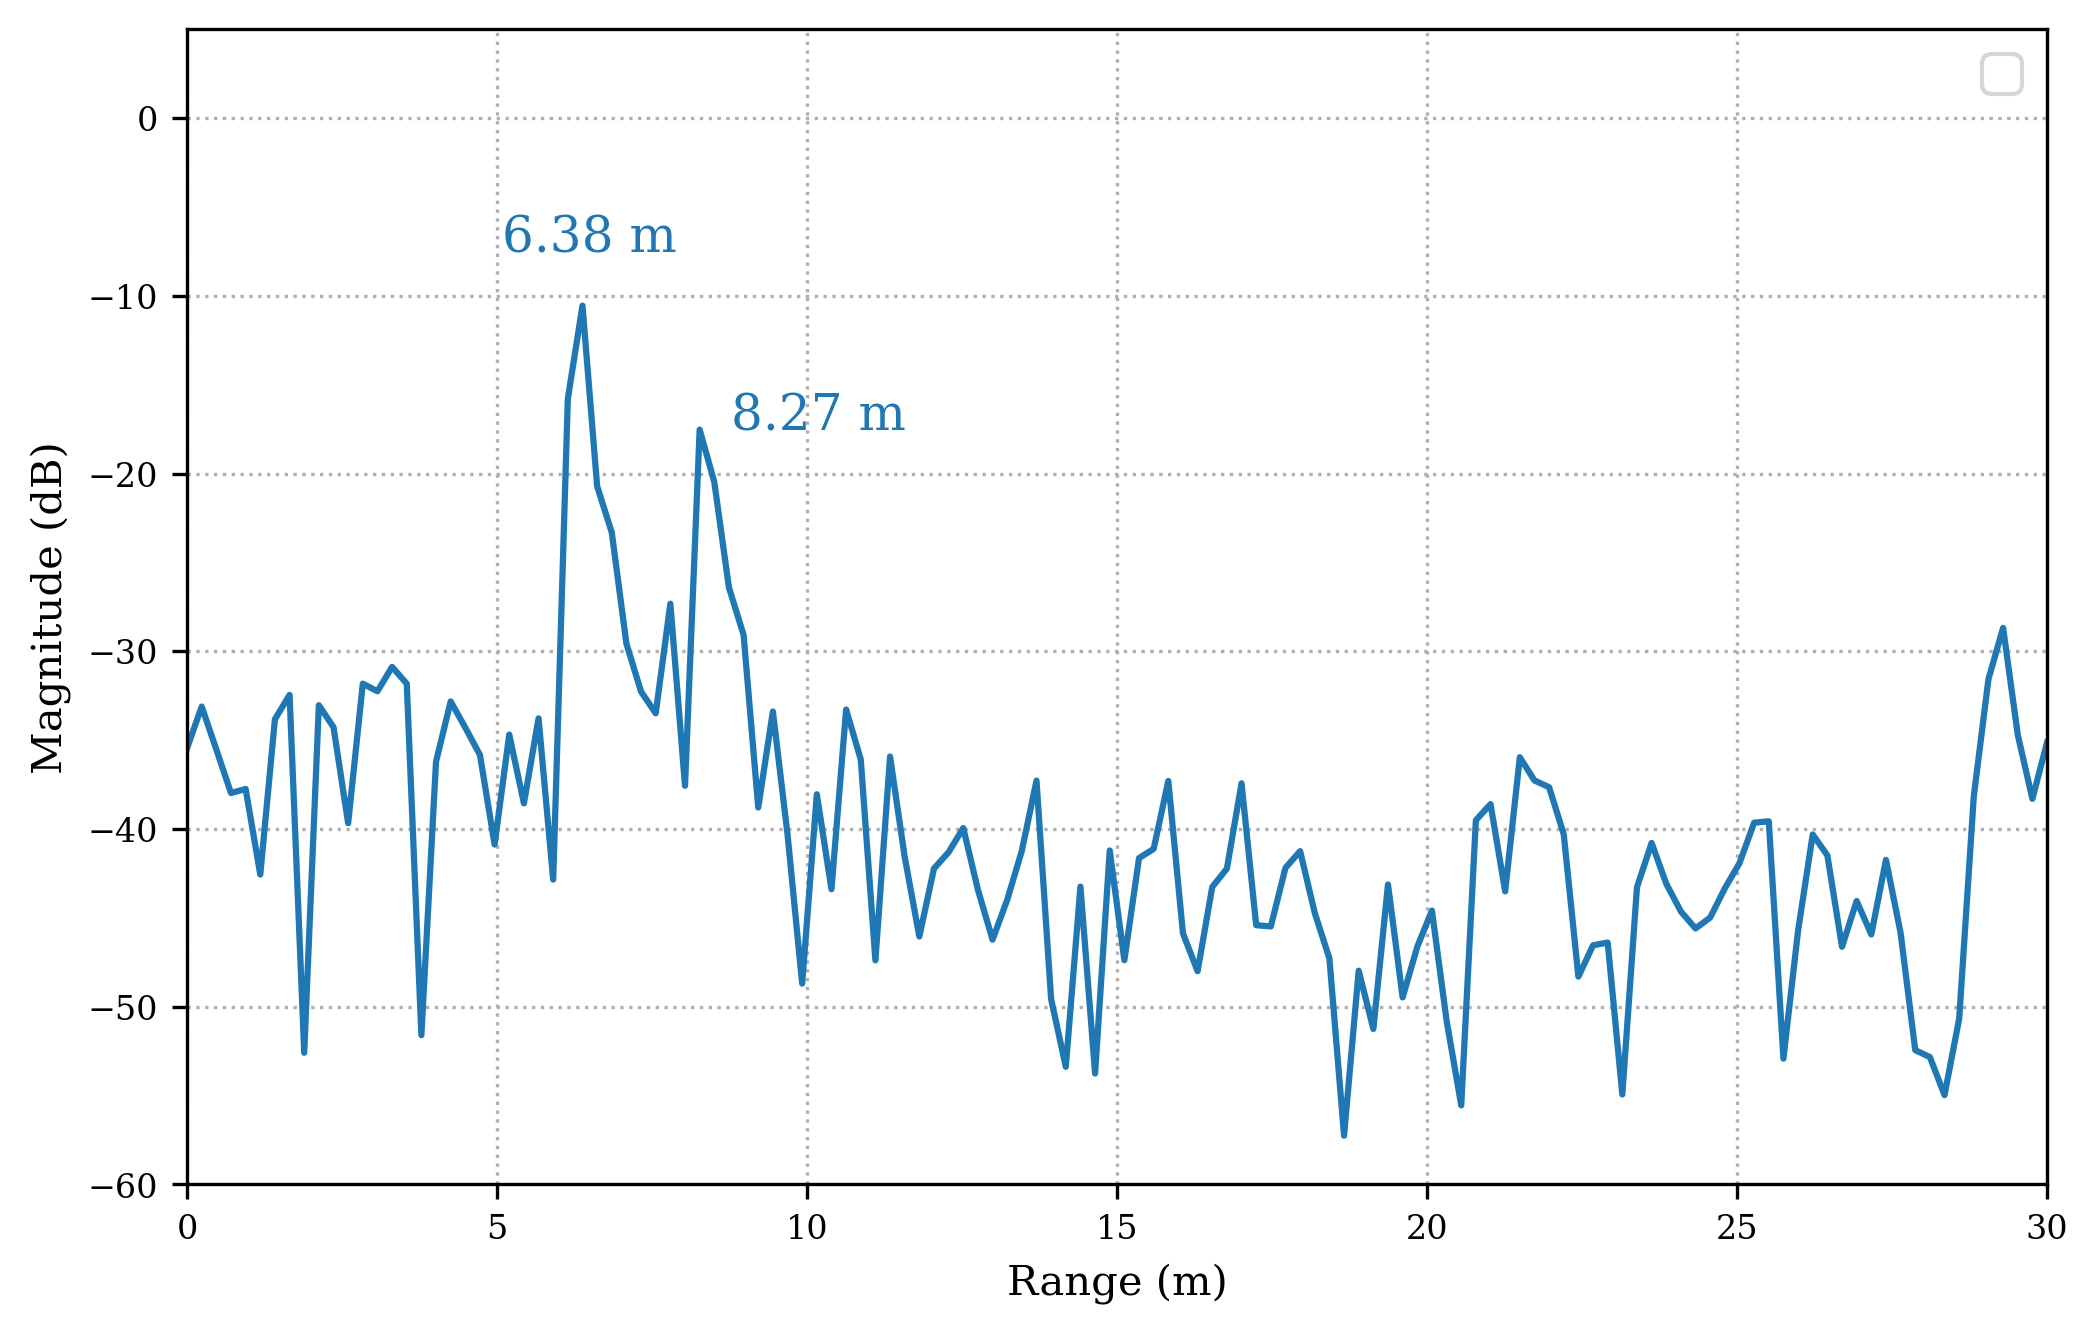

In [21]:
dir = '/home/hui/bladerf_sfcw_radar/data/'
prefix = 'res_0'
i=47
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile_range_res, calibrated_channel_response_res, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

c = 3e8  # Speed of light
max_range = c / (2 * SAMPLING_RATE)
range_axis = np.linspace(0, max_range, num_steps)
target_positions_m = [1.8, 1.8, 3.5, 5.3]
output_filename = "resEx0.eps"

plt.figure(figsize=[8,5])

channel_response_sky_cal = calibrated_channel_response_res - calibrated_channel_response_0
a_scan_sky_cal = np.fft.ifft(channel_response_sky_cal)
ascan_db = 20 * np.log10(np.abs(a_scan_sky_cal) + 1e-12) - 5
plt.plot(range_axis,ascan_db)
peak_index = np.argmax(ascan_db)
peak_range = range_axis[peak_index]
peak_db = ascan_db[peak_index]
plt.text(peak_range - 1.3, peak_db+3, f'{peak_range:.2f} m', fontsize=12, color=plt.gca().lines[-1].get_color())

peak_index = find_index(ascan_db,-3)
peak_range = range_axis[peak_index]
peak_db = ascan_db[peak_index]
plt.text(peak_range + 0.5, peak_db, f'{peak_range:.2f} m', fontsize=12, color=plt.gca().lines[-1].get_color())

# --- 5. Finalize and Save Figure ---
plt.xlabel('Range (m)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, linestyle=':')
plt.xlim(0, max_range)
plt.ylim(-60, 5)
plt.legend()

plt.savefig(output_filename, bbox_inches='tight')
print(f"Figure saved as '{output_filename}'")
plt.show()